# RB-PLPE — PPO Pathway Generator Training
**Stage:** ML Pipeline Stage 4 — Reinforcement Learning
**Input:** `data/cleaned/courses_cleaned.csv`
**Output:** `models/ppo_agent.zip`

### What this notebook does
1. Load and verify the cleaned courses dataset
2. Build the custom Gymnasium environment (LearningPathEnv)
3. Define State, Action, and Reward
4. Train the PPO agent
5. Evaluate the trained agent
6. Save the model to models/ppo_agent.zip
7. Test end-to-end pathway generation



## Install Required Packages

In [4]:
# Install if not already installed
import subprocess
subprocess.run(["pip", "install", "stable-baselines3", "gymnasium",
                "pandas", "numpy", "matplotlib", "torch"], check=True)
print("All packages ready")

All packages ready


## Imports & Paths

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import EvalCallback, BaseCallback
from stable_baselines3.common.monitor import Monitor
import os, warnings
warnings.filterwarnings("ignore")

# ── Paths ──
COURSES_PATH = "../data/cleaned/courses_cleaned.csv"
MODEL_PATH   = "../models/ppo_agent"
LOG_PATH     = "../models/ppo_logs/"

os.makedirs("../models", exist_ok=True)
os.makedirs(LOG_PATH,    exist_ok=True)

print("Imports done")
print(f"Courses path: {COURSES_PATH}")
print(f"Model path  : {MODEL_PATH}")


Imports done
Courses path: ../data/cleaned/courses_cleaned.csv
Model path  : ../models/ppo_agent


## Load & Verify Courses Dataset

In [6]:
df = pd.read_csv(COURSES_PATH)
df = df.dropna(subset=["skills"]).reset_index(drop=True)

print("=" * 50)
print("COURSES DATASET REPORT")
print("=" * 50)
print(f"Total courses : {len(df)}")
print(f"Columns       : {df.columns.tolist()}")
print(f"Difficulty    : {df['difficulty'].value_counts().to_dict()}")
print(f"Rating range  : {df['rating'].min()} - {df['rating'].max()}")
print(f"Duration range: {df['duration_hrs'].min()} - {df['duration_hrs'].max()} hrs")
print(f"\nSample courses:")
df[["course_title", "skills", "difficulty", "rating"]].head(5)

COURSES DATASET REPORT
Total courses : 766
Columns       : ['course_title', 'skills', 'difficulty', 'rating', 'course_url', 'duration_hrs', 'platform', 'category']
Difficulty    : {'Intermediate': 572, 'Beginner': 131, 'Advanced': 63}
Rating range  : 3.5 - 5.0
Duration range: 1.0 - 480.0 hrs

Sample courses:


,course_title,skills,difficulty,rating
0,Road to the CISO – Culminating Project Course,"cyber-security regulation, cybersecurity staff...",Intermediate,5.0
1,Regression Analysis: Simplify Complex Data Rel...,"predictive modelling, statistical analysis, py...",Intermediate,5.0
2,Google Business Intelligence Professional Cert...,"data modeling, business analysis, bigquery, sh...",Advanced,5.0
3,Introduction to Cybersecurity Essentials,"information security (infosec), cyberattacks, ...",Beginner,4.9
4,Improving Deep Neural Networks: Hyperparameter...,"tensorflow, deep learning, mathematical optimi...",Intermediate,4.9


## Extract All Unique Skills from Dataset

In [7]:
# Extract all unique skills from the course pool
# These become the dimensions of our state space
all_skills = set()
for skill_str in df["skills"].dropna():
    for sk in skill_str.split(","):
        sk = sk.strip().lower()
        if len(sk) > 2 and sk.isascii():
            all_skills.add(sk)

SKILL_LIST = sorted(list(all_skills))
SKILL_INDEX = {skill: i for i, skill in enumerate(SKILL_LIST)}

print(f"Total unique skills in dataset: {len(SKILL_LIST)}")
print(f"\nSample skills:")
print(SKILL_LIST[:20])

Total unique skills in dataset: 1724

Sample skills:
['-\tdatenanalyse', '-\tdatenbereinigung', '-\tdatenvisualisierung (dataviz)', '-\tfallstudie', '-\tjob-portfolio', '-\tr markdown', '-\tr-programmierung', '-\trstudio', '-\ttabellenkalkulation', '-\ttableau-software', '3d modeling', '3d printing', '3d reconstruction', 'a/b testing', 'a/b testing and model deployment', 'a/b/n testing', 'access structure', 'accessibility', 'accounting', 'accrual']


## Custom Gymnasium Environment

### RL Components:
- **State**  → Binary vector showing which missing skills are still uncovered
- **Action** → Index of the course to recommend next (0 to N-1)
- **Reward** → Positive for covering a skill, negative for redundancy

In [9]:
class LearningPathEnv(gym.Env):
    """
    Custom Gymnasium Environment for Learning Pathway Generation

    State  : Binary vector of size len(missing_skills)
             1 = skill still missing, 0 = skill covered by a course
    Action : Integer index — which course to recommend next
    Reward :
        +10 * (rating/5) for each new missing skill covered
        -2  if course covers no new missing skills (redundant)
        -5  if same course selected twice (duplicate)
        +1  difficulty bonus (Beginner early, Advanced late)
    """

    metadata = {"render_modes": []}

    def __init__(self, courses_df, missing_skills, max_steps=None):
        super().__init__()

        self.courses_df     = courses_df.reset_index(drop=True)
        self.missing_skills = [s.strip().lower() for s in missing_skills]
        self.n_courses      = len(self.courses_df)
        self.n_skills       = len(self.missing_skills)
        self.max_steps      = max_steps or min(15, self.n_skills * 3)

        # Action space: pick any course
        self.action_space = spaces.Discrete(self.n_courses)

        # Observation space: binary skill coverage vector
        # + normalized step counter
        self.observation_space = spaces.Box(
            low   = 0.0,
            high  = 1.0,
            shape = (self.n_skills + 1,),
            dtype = np.float32
        )

        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # All skills start as missing (1.0)
        self.skill_coverage = np.ones(self.n_skills, dtype=np.float32)
        self.selected_courses = set()
        self.current_step = 0
        obs = self._get_obs()
        return obs, {}

    def _get_obs(self):
        # Skill coverage vector + normalized progress
        progress = np.array([self.current_step / self.max_steps], dtype=np.float32)
        return np.concatenate([self.skill_coverage, progress])

    def step(self, action):
        self.current_step += 1
        reward = 0.0
        info   = {}

        course = self.courses_df.iloc[int(action)]
        course_skills = str(course["skills"]).lower()
        course_rating = float(course["rating"])
        course_diff   = str(course["difficulty"])

        # ── Reward: cover missing skills ──
        skills_covered = []
        for i, skill in enumerate(self.missing_skills):
            if skill in course_skills and self.skill_coverage[i] == 1.0:
                self.skill_coverage[i] = 0.0   # mark as covered
                reward += 10.0 * (course_rating / 5.0)
                skills_covered.append(skill)

        # ── Penalty: redundant course (no new skills) ──
        if len(skills_covered) == 0:
            reward -= 2.0

        # ── Penalty: duplicate course ──
        if action in self.selected_courses:
            reward -= 5.0
        else:
            self.selected_courses.add(action)

        # ── Bonus: correct difficulty ordering ──
        # Beginner courses early, Advanced courses late
        if course_diff == "Beginner" and self.current_step <= 3:
            reward += 1.5
        elif course_diff == "Intermediate" and 3 < self.current_step <= 7:
            reward += 1.0
        elif course_diff == "Advanced" and self.current_step > 7:
            reward += 2.0

        # ── Done conditions ──
        all_covered  = np.sum(self.skill_coverage) == 0
        max_reached  = self.current_step >= self.max_steps
        terminated   = bool(all_covered)
        truncated    = bool(max_reached and not all_covered)

        info["skills_covered"] = skills_covered
        info["total_covered"]  = int(self.n_skills - np.sum(self.skill_coverage))

        return self._get_obs(), reward, terminated, truncated, info

    def render(self):
        covered = int(self.n_skills - np.sum(self.skill_coverage))
        print(f"Step {self.current_step}: {covered}/{self.n_skills} skills covered")

print("LearningPathEnv defined successfully")


LearningPathEnv defined successfully


## Validate Environment with Gymnasium Checker

In [10]:
# Test with sample missing skills
sample_missing = [
    "machine learning", "deep learning", "python",
    "sql", "data visualization", "statistics"
]

# Create test environment
test_env = LearningPathEnv(df, sample_missing)

# Gymnasium environment checker — validates obs/action spaces
check_env(test_env, warn=True)
print("Environment check passed!")

# Quick manual test
obs, _ = test_env.reset()
print(f"\nObservation shape : {obs.shape}")
print(f"Action space size : {test_env.action_space.n}")
print(f"Initial obs       : {obs}")

# Random action test
action = test_env.action_space.sample()
obs, reward, terminated, truncated, info = test_env.step(action)
print(f"\nRandom action     : {action}")
print(f"Reward            : {reward}")
print(f"Skills covered    : {info['skills_covered']}")
print(f"Total covered     : {info['total_covered']}/{len(sample_missing)}")


Environment check passed!

Observation shape : (7,)
Action space size : 766
Initial obs       : [1. 1. 1. 1. 1. 1. 0.]

Random action     : 210
Reward            : -2.0
Skills covered    : []
Total covered     : 0/6


## Training Reward Callback (for plotting)

In [11]:
class RewardCallback(BaseCallback):
    """
    Logs episode rewards during training so we can plot
    the learning curve after training
    """
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self.episode_lengths = []

    def _on_step(self):
        if len(self.model.ep_info_buffer) > 0:
            for ep_info in self.model.ep_info_buffer:
                self.episode_rewards.append(ep_info["r"])
                self.episode_lengths.append(ep_info["l"])
        return True

print("Callback defined")


Callback defined


## Train PPO Agent

> This cell trains the PPO agent. Takes ~5-15 minutes on CPU, ~2-5 min on GPU.
> Increase `total_timesteps` for better performance.


In [16]:

# ── Training missing skills ──
# Use a diverse set covering all IT domains
training_missing_skills = [
    # Data & ML
    "machine learning", "deep learning", "python", "sql",
    "data visualization", "statistics", "data analysis",
    "pandas", "numpy", "tensorflow",
    # Web & Software
    "javascript", "react", "node", "html", "css",
    "java", "python programming", "rest api",
    # DevOps & Cloud
    "docker", "kubernetes", "aws", "devops", "linux",
    # Security & DB
    "cybersecurity", "database management", "mysql",
    # Other IT
    "project management", "agile", "git"
]

# ── Create training environment ──
train_env = Monitor(LearningPathEnv(df, training_missing_skills))

# ── PPO hyperparameters ──
model = PPO(
    policy          = "MlpPolicy",
    env             = train_env,
    verbose         = 1,
    learning_rate   = 3e-4,
    n_steps         = 1024,
    batch_size      = 64,
    n_epochs        = 10,
    gamma           = 0.99,      # discount factor
    gae_lambda      = 0.95,      # GAE parameter
    clip_range      = 0.2,       # PPO clip range
    ent_coef        = 0.01,      # entropy coefficient
    
)

print("PPO model created")
print(f"Policy network: {model.policy}")
print(f"\nStarting training...")
print(f"Training on {len(training_missing_skills)} skills")
print(f"Course pool size: {len(df)} courses")
print("-" * 50)

# ── Training callback ──
reward_callback = RewardCallback()

# ── Train ──
# Increase total_timesteps for better results
# 50000  = quick test (~5 min CPU)
# 200000 = good results (~20 min CPU)
# 500000 = best results (~1 hr CPU / 15 min GPU)
model.learn(
    total_timesteps   = 50000,
    callback          = reward_callback,
    progress_bar      = False,
)

print("\nTraining complete!")


Using cpu device
Wrapping the env in a DummyVecEnv.
PPO model created
Policy network: ActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=30, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=30, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=64, out_features=766, bias=True)
  (value_net): Linear(in_features=64, out_features=1, bias=True)
)

Starting training...
Training on 29 skills


## Save Trained Model

In [17]:
model.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}.zip")

# Verify file exists
import os
if os.path.exists(MODEL_PATH + ".zip"):
    size = os.path.getsize(MODEL_PATH + ".zip") / 1024
    print(f"File size: {size:.1f} KB")
    print("Model saved successfully!")
else:
    print("ERROR: Model file not found!")

Model saved to: ../models/ppo_agent.zip
File size: 758.9 KB
Model saved successfully!


## Plot Learning Curve

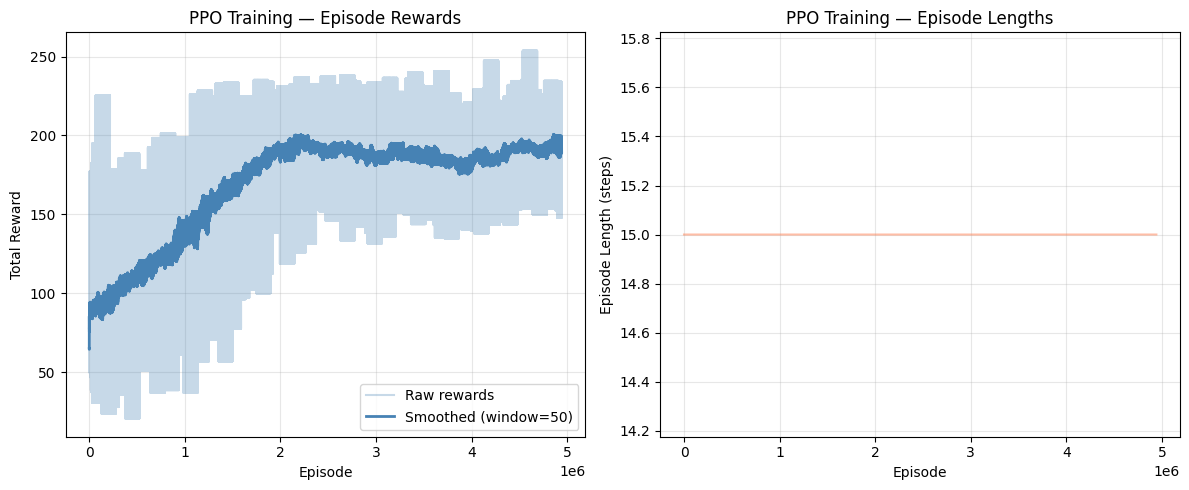

Total episodes    : 4941850
Final avg reward  : 189.96
Best episode reward: 253.70


In [18]:
if len(reward_callback.episode_rewards) > 0:
    rewards = reward_callback.episode_rewards

    # Smooth rewards with moving average
    window = min(50, len(rewards) // 10)
    if window > 1:
        smoothed = pd.Series(rewards).rolling(window=window).mean()
    else:
        smoothed = pd.Series(rewards)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(rewards, alpha=0.3, color="steelblue", label="Raw rewards")
    plt.plot(smoothed, color="steelblue", linewidth=2, label=f"Smoothed (window={window})")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title("PPO Training — Episode Rewards")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(reward_callback.episode_lengths, alpha=0.5, color="coral")
    plt.xlabel("Episode")
    plt.ylabel("Episode Length (steps)")
    plt.title("PPO Training — Episode Lengths")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("../models/training_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Total episodes    : {len(rewards)}")
    print(f"Final avg reward  : {np.mean(rewards[-50:]):.2f}")
    print(f"Best episode reward: {max(rewards):.2f}")
else:
    print("No episode data collected — increase total_timesteps")


## Evaluate Trained Agent

In [19]:
# Load the saved model
trained_model = PPO.load(MODEL_PATH)
print(f"Model loaded from: {MODEL_PATH}.zip")

# Test using the SAME training skills
# Model expects observation size = len(training_missing_skills) + 1
test_cases = [
    training_missing_skills[:5],   # first 5 skills
    training_missing_skills[5:10], # next 5 skills
    training_missing_skills[10:15],# next 5 skills
    training_missing_skills[:10],  # first 10 skills
]

print("\n" + "=" * 60)
print("EVALUATION RESULTS")
print("=" * 60)

for i, missing in enumerate(test_cases):
    print(f"\nTest {i+1}: Missing skills = {missing}")
    print("-" * 50)

    # Use same skill count as training
    env = LearningPathEnv(df, training_missing_skills)
    obs, _ = env.reset()
    pathway = []
    done = False
    total_reward = 0

    while not done and len(pathway) < len(missing) + 2:
        action, _ = trained_model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(int(action))
        total_reward += reward
        done = terminated or truncated

        course = df.iloc[int(action)]
        if info["skills_covered"]:
            pathway.append({
                "rank"      : len(pathway) + 1,
                "title"     : course["course_title"],
                "covers"    : info["skills_covered"],
                "difficulty": course["difficulty"],
                "rating"    : course["rating"],
            })

    print(f"Total reward   : {total_reward:.2f}")
    print(f"Skills covered : {info['total_covered']}/{len(training_missing_skills)}")
    print(f"Pathway ({len(pathway)} courses):")
    for c in pathway:
        print(f"  {c['rank']}. {c['title'][:50]:50} | covers: {c['covers']} | {c['difficulty']} | {c['rating']}")

Model loaded from: ../models/ppo_agent.zip

EVALUATION RESULTS

Test 1: Missing skills = ['machine learning', 'deep learning', 'python', 'sql', 'data visualization']
--------------------------------------------------
Total reward   : 88.20
Skills covered : 18/29
Pathway (2 courses):
  1. IBM Full Stack Software Developer Professional Cer | covers: ['python', 'sql', 'data analysis', 'pandas', 'numpy', 'javascript', 'react', 'node', 'html', 'css', 'java', 'docker', 'kubernetes', 'devops', 'git'] | Advanced | 4.5
  2. IBM Data Warehouse Engineer Professional Certifica | covers: ['linux', 'database management', 'mysql'] | Advanced | 4.7

Test 2: Missing skills = ['statistics', 'data analysis', 'pandas', 'numpy', 'tensorflow']
--------------------------------------------------
Total reward   : 88.20
Skills covered : 18/29
Pathway (2 courses):
  1. IBM Full Stack Software Developer Professional Cer | covers: ['python', 'sql', 'data analysis', 'pandas', 'numpy', 'javascript', 'react', 'node',

## Compare PPO vs Rule-Based Fallback

In [20]:
def rule_based_pathway(courses_df, missing_skills):
    """Simple rule-based baseline for comparison"""
    pathway = []
    used = set()
    for skill in missing_skills:
        for diff in ["Beginner", "Intermediate", "Advanced"]:
            mask = (
                courses_df["skills"].str.lower().str.contains(skill, na=False) &
                (courses_df["difficulty"] == diff)
            )
            matched = courses_df[mask]
            matched = matched[~matched.index.isin(used)]
            if len(matched) > 0:
                best = matched.sort_values("rating", ascending=False).iloc[0]
                used.add(best.name)
                pathway.append(best["course_title"])
                break
    return pathway

# Use training_missing_skills — must match model observation size
test_missing = training_missing_skills[:6]

# PPO pathway — environment must use training_missing_skills
env = LearningPathEnv(df, training_missing_skills)
obs, _ = env.reset()
ppo_pathway = []
done = False

while not done and len(ppo_pathway) < 8:
    action, _ = trained_model.predict(obs, deterministic=True)
    obs, _, terminated, truncated, info = env.step(int(action))
    done = terminated or truncated
    if info["skills_covered"]:
        ppo_pathway.append(df.iloc[int(action)]["course_title"])

# Rule-based pathway
rb_pathway = rule_based_pathway(df, test_missing)

print("=" * 60)
print(f"Test skills: {test_missing}")
print("=" * 60)
print(f"\nPPO Pathway ({len(ppo_pathway)} courses):")
for i, c in enumerate(ppo_pathway, 1):
    print(f"  {i}. {c}")
print(f"\nRule-Based Pathway ({len(rb_pathway)} courses):")
for i, c in enumerate(rb_pathway, 1):
    print(f"  {i}. {c}")

Test skills: ['machine learning', 'deep learning', 'python', 'sql', 'data visualization', 'statistics']

PPO Pathway (2 courses):
  1. IBM Full Stack Software Developer Professional Certificate
  2. IBM Data Warehouse Engineer Professional Certificate

Rule-Based Pathway (6 courses):
  1. Fundamentals of Reinforcement Learning
  2. Intro to Machine Learning with PyTorch
  3. An Introduction to Interactive Programming in Python (Part 2)
  4. Introduction to Structured Query Language (SQL)
  5. Introduction to Data Analytics
  6. Introduction to Probability and Data with R


## Done!

**Output file:** `models/ppo_agent.zip`

### What happens next:
- `ml/pathway_generator.py` automatically detects `ppo_agent.zip`
- It switches from rule-based fallback to the trained PPO agent
- No code changes needed — just restart FastAPI

### To improve results:
- Increase `total_timesteps` in Cell 8 to 200,000 or 500,000
- Run on Google Colab with T4 GPU for faster training
- Add more diverse missing skills to `training_missing_skills`
